<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


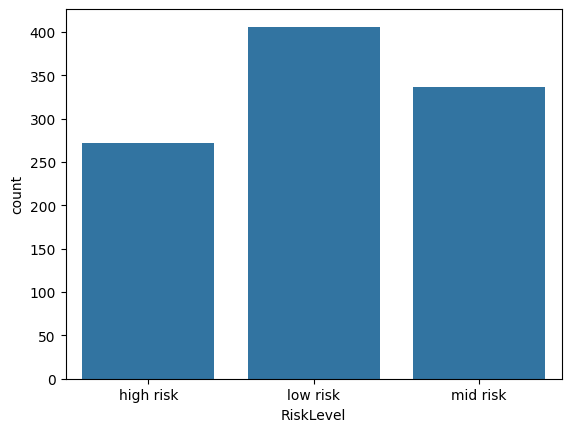

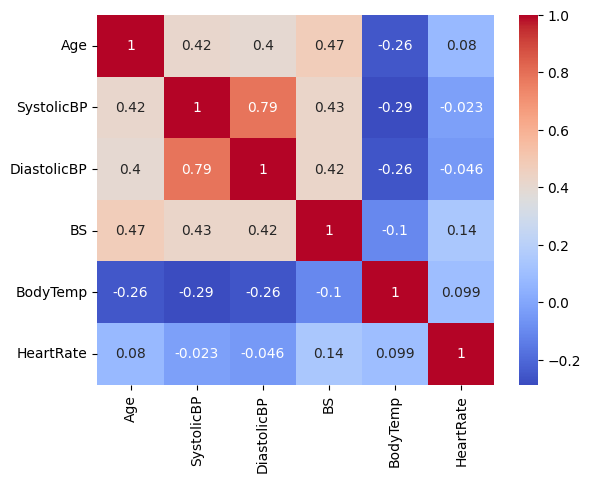

In [ ]:
#----------Data Analysis (Understanding the data)----------

#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Loading Data
df = pd.read_csv("../data/raw/maternal_health.csv")
df.head()

#Checking total rows, null values, data types, class balance, feature ranges
df.shape
df.info()
df.describe()
df.isnull().sum()
df["RiskLevel"].value_counts()

#Visualize
sns.countplot(x="RiskLevel", data=df)
plt.show()

#Correlation
numeric_df = df.drop(columns=['RiskLevel'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [6]:
#----------Data Preprocessing----------

#Feature Seperation
X = df.drop("RiskLevel", axis =1)
y = df["RiskLevel"]

#Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(le.classes_)

#Split Dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

['high risk' 'low risk' 'mid risk']
